# DPAC train & eval 1 Model on ALL data with Default HP values

Logan Wong

law3082

Load the embeddings

DPAC did pretraining to learn features from images.
But I'm not using images, I'm using Tweets.
The Tweets were embedded into vectors using a pretrained LLM, all-mpnet-base-v2, which follows the SBERT architecture.

Do clustering using DPAC

Neither paper split their data into train/valid/test
So neither paper did hyperparameter tuning.

But, the DPAC paper had these hyperparameters:
Weight exponent, m: 1.03
Temperature, tau: 0.5
Adam Optimizer LR: 0.0001
1000 epochs for the pre-training step
200 epochs for the clustering step
Cluster number, K: predefined for the algorithms…

Incremental Clustering for Event Detection on Twitter paper had a dynamic incremental learning algo that did NOT need T, the # of clusters, predefined.

DPAC DID need K, the # of clusters, to be predefined.

In [1]:
import sys
import os

# Add the DPAC program folder to path
dpac_path = '/home/stu5/s5/law3082/Courses/MLDD/Deep-Probability-Aggregation-Clustering/PAC_DPAC_program/'
if dpac_path not in sys.path:
    sys.path.append(dpac_path)

In [2]:
import pandas as pd
import time

import argparse
import torch
import numpy as np
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

from models import Network 
from contrastive_loss import InfonceLoss
import torch.nn.functional as F

import matplotlib.pyplot as plt
import seaborn as sns

# Evaluation metrics
# from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from sklearn.metrics.cluster import adjusted_mutual_info_score, adjusted_rand_score

# Plotting
from sklearn.manifold import TSNE


In [3]:
os.environ["CUDA_VISIBLE_DEVICES"]="6"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
def convert(seconds):
    seconds = seconds % (24 * 3600)
    hour = seconds // 3600
    seconds %= 3600
    minutes = seconds // 60
    seconds %= 60

    return "%d:%02d:%02d" % (hour, minutes, seconds)

# Load Embeddings

In [5]:
embeddings_raw = np.load('data/event2012_embeddings.npy')
# Convert to a Float Tensor & move to GPU
embeddings = torch.from_numpy(embeddings_raw).float().to(device)

# Load the metadata to track tweet IDs
metadata = pd.read_csv('data/event2012_metadata.csv')

print(f"Loaded {embeddings.shape[0]} embeddings with dimension {embeddings.shape[1]}")

Loaded 68841 embeddings with dimension 768


In [6]:
# This class is based on ContrastiveLearningDataset, found in 
# /Courses/MLDD/Deep-Probability-Aggregation-Clustering/PAC_DPAC_program/data/
class TwitterVectorDataset(Dataset):
    def __init__(self, vecs):
        self.vecs = vecs
        
    def __len__(self):
        return len(self.vecs)

    def __getitem__(self, idx):
        x = self.vecs[idx]
        # DPAC expects (weak, strong, ori). 
        # "views" are simulated by adding 1% and 5% noise to the vectors.
        weak = x + torch.randn_like(x) * 0.01
        strong = x + torch.randn_like(x) * 0.05
        return (weak, strong, x), 0 # 0 is a placeholder label

In [7]:
# Initialize loader
dataset = TwitterVectorDataset(embeddings)
batch_size = 256
ins_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

# a mismatch between batch size and the number of tweets in the dataset
# total number of tweets isn't perfectly divisible by 256, the very last batch is smaller (a "partial batch")
# tell DataLoader to ignore the last tiny leftover piece of data
# DataLoader drops the "partial batch" 

In [8]:
# Define a Backbone for vectors
# original DPAC repo uses ResNet (which is for images)
# This is an MLP backbone to handle Twitter vectors
class TwitterBackbone(nn.Module):
    def __init__(self, input_dim=768, rep_dim=128):
        super().__init__()
        self.rep_dim = rep_dim # The Network class NEEDS this attribute
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, rep_dim)
        )
        
    def forward(self, x):
        return self.encoder(x)

In [9]:
input_dim = embeddings.shape[1]        # 768
# DPAC 'z' space dimension
feature_dim = 128               
my_backbone = TwitterBackbone(input_dim=input_dim, rep_dim=feature_dim)

# target number of clusters (events) aka class_num
num_events = 1603
# Wrap backbone in the DPAC Network class and move to GPU
model = Network(my_backbone, my_backbone.rep_dim, class_dim=num_events).to(device)

print(f"Model initialized on {device} with input dimension {input_dim}")

Model initialized on cuda with input dimension 768


In [10]:
print(model.cluster_head)

Sequential(
  (0): Linear(in_features=128, out_features=128, bias=True)
  (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=128, bias=True)
  (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU()
  (6): Linear(in_features=128, out_features=1603, bias=True)
)


In [11]:
# Original DPAC paper: Config 0
hps = {
    "weight_exponent_m": 1.03,
    "lr":0.0001,
    "weight_decay":0.0001,
    "temp":0.5,
    "epochs": 200,
    "K": num_events
}

# Config 1
# hps = {
#     "weight_exponent_m": 1.01,
#     "lr":0.0001,
#     "weight_decay":0.0001,
#     "temp":0.1,
#     "epochs": 200,
#     "K": num_events
# }

# Config 2
# hps = {
#     "weight_exponent_m": 1.05,
#     "lr":0.0001,
#     "weight_decay":0.0001,
#     "temp":0.7,
#     "epochs": 200,
#     "K": num_events
# }



# hps = {
#     "weight_exponent_m": 1.03,
#     "lr":0.0001,
#     "weight_decay":0.0001,
#     "temp": 0.5,
#     "epochs": 125,    # Loss curves show it plateaus at around 100-125 
#     "K": num_events
# }

In [12]:
# Define optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=hps['lr'], weight_decay=hps['weight_decay'])

# Define Contrastive Loss (InfoNCE)
criterion = InfonceLoss(batch_size=batch_size, temperature=hps['temp'], device=device).to(device)

# Setup the GradScaler for mixed-precision training
scaler = torch.cuda.amp.GradScaler()

print(f"Optimizer and Criterion ready on {device}")

Optimizer and Criterion ready on cuda


/tmp/ipykernel_2952409/1930107486.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


# Training

In [13]:
def train_model(model, ins_loader, optimizer, criterion, scaler, device, m):
    model.train()
    loss_epoch = {'loss1': 0, 'loss2': 0}
    
    for step, ((weak, strong, ori), _) in enumerate(ins_loader):
        # Move all versions of the tweet vector to the GPU
        weak = weak.to(device)
        strong = strong.to(device)
        ori = ori.to(device)
        
        # Concatenate weak and strong for contrastive learning
        img = torch.cat((weak, strong), dim=0)
        
        optimizer.zero_grad()
        
        with torch.amp.autocast('cuda'):
            # Forward pass
            z, p1, _ = model(img)
            
            # DPAC Clustering logic (Probability Aggregation)
            # Generate target distribution 'q'
            q, p = model.PAC_online(ori, m=m) 

            # model's last layer is a Linear layer, NOT softmax
            # THUS, convert raw logits (p1) into log-probabilities
            log_p1 = F.log_softmax(p1, dim=1)
            
            # Calculate Loss
            loss1 = criterion(z)         # Contrastive Loss (keeps tweets together)
            # loss2 = kldiv(q, p1)         # Clustering Loss (pushes tweets into events)
            loss2 = F.kl_div(log_p1, q, reduction='batchmean')
            
            loss = loss1 + loss2

        # Backprop
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        loss_epoch['loss1'] += loss1.item() / len(ins_loader)
        loss_epoch['loss2'] += loss2.item() / len(ins_loader)
        
    return loss_epoch

In [14]:
# Train and Save the model
history = {
    'contrastive': [],
    'clustering': []
}

# filename should include m, LR, weight decay, and temp
m_str = str(hps["weight_exponent_m"]).replace('.', '_')
lr_str = str(hps["lr"]).replace('.', '_')
wd_str = str(hps["weight_decay"]).replace('.', '_')
temp_str = str(hps["temp"]).replace('.', '_')
model_save_path = f'models/event2012_DPAC_m_{m_str}_lr_{lr_str}_wd_{wd_str}_temp{temp_str}_k_{num_events}.tar'
# model_save_path = 'models/event2012_DPAC_model_traind_on_all_data.tar'

epochs = hps["epochs"]
print("Training started")
start_time = time.time()
for epoch in tqdm(range(epochs)):
    # Run 1 full pass thru Twitter data
    losses = train_model(model, ins_loader, optimizer, criterion, scaler, device, m=hps["weight_exponent_m"])
    history['contrastive'].append(losses['loss1'])
    history['clustering'].append(losses['loss2'])
    
    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | "
              f"Contrastive Loss: {losses['loss1']:.4f} | "
              f"Clustering Loss: {losses['loss2']:.4f}")
        
    # Save model weights
    if (epoch + 1) % 50 == 0:
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': losses,
        }, f"checkpoints/checkpoint_epoch_{epoch+1}.tar")

end_time = time.time()
print("DONE!!!")
training_duration = end_time - start_time
time_in_minutes_and_seconds = convert(training_duration)

Training started


  5%|█████▍                                                                                                       | 10/200 [01:48<33:42, 10.65s/it]

Epoch [10/200] | Contrastive Loss: 4.4346 | Clustering Loss: 1.7585


 10%|██████████▉                                                                                                  | 20/200 [03:32<31:49, 10.61s/it]

Epoch [20/200] | Contrastive Loss: 4.4026 | Clustering Loss: 2.2427


...

Epoch [180/200] | Contrastive Loss: 4.3322 | Clustering Loss: 2.8633


 95%|██████████████████████████████████████████████████████████████████████████████████████████████████████▌     | 190/200 [36:30<02:27, 14.77s/it]

Epoch [190/200] | Contrastive Loss: 4.3314 | Clustering Loss: 2.8453


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [38:41<00:00, 11.61s/it]

Epoch [200/200] | Contrastive Loss: 4.3298 | Clustering Loss: 2.7732
DONE!!!


In [19]:
print(f"Time taken: {time_in_minutes_and_seconds}")
# Time taken: 0:38:41

Time taken: 0:38:41


In [16]:
# Save the state_dict and hyperparameters
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'hps': hps,
    'num_events': num_events
}, model_save_path)

print(f"Model saved successfully to {model_save_path}")

Model saved successfully to models/event2012_DPAC_m_1_03_lr_0_0001_wd_0_0001_temp0_5_k_1603.tar


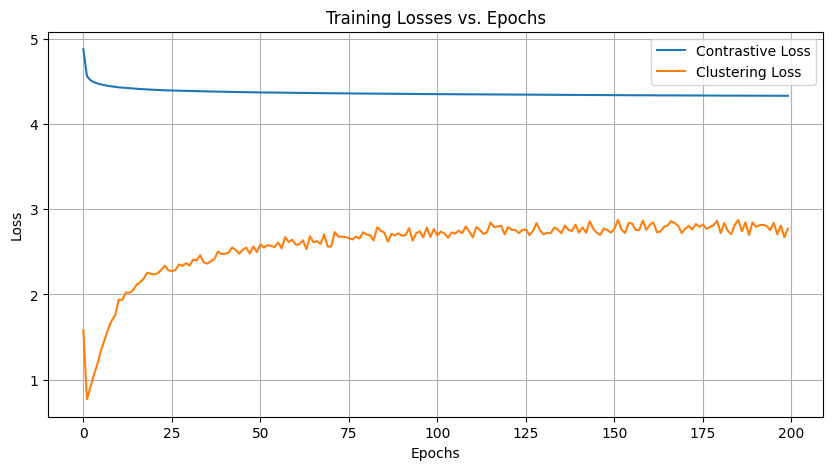

In [17]:
# Plot losses
plot_save_path = f'plots/loss_curves_m{m_str}_lr{lr_str}_wd{wd_str}_temp{temp_str}_k_{num_events}.png'

plt.figure(figsize=(10, 5))
plt.plot(history['contrastive'], label='Contrastive Loss')
plt.plot(history['clustering'], label='Clustering Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Losses vs. Epochs')
plt.legend()
plt.grid(True)

plt.savefig(plot_save_path, dpi=300, bbox_inches='tight')
plt.show()

# Evaluation

In [20]:
model_path = 'models/event2012_DPAC_m_1_03_lr_0_0001_wd_0_0001_temp0_5_k_1603.tar'
checkpoint = torch.load(model_path, map_location=device)

# Load the weights into the model
model.load_state_dict(checkpoint['model_state_dict'])

/tmp/ipykernel_2952409/2008720735.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)


<All keys matched successfully>

In [21]:
# Inference (No gradients needed)
model.eval()
with torch.no_grad():
    # test_forward returns (features, probabilities)
    _, probs = model.test_forward(embeddings)
    
    # Get cluster index with highest probability
    assignments = torch.argmax(probs, dim=1)
    preds = assignments.cpu().numpy()

# Get ground truth labels from metadata
y_true = metadata['label'].values

print(f"Clustering finished for {len(preds)} tweets.")

Clustering finished for 68841 tweets.


In [23]:
# Calculate Metrics
ari = adjusted_rand_score(y_true, preds)
ami = adjusted_mutual_info_score(y_true, preds)

print(f"ARI (Adjusted Rand Index): {ari:.4f}")
print(f"AMI (Adjusted Mutual Information): {ami:.4f}")

# PAPER BASELINE:
# ARI: 0.63
# AMI: 0.86

# My Replication of the Paper Baseline by running the README:
# ARI 0.59693
# AMI 0.840435  

# ARI measures how many pairs of tweets are correctly grouped together or correctly separated. 
# AMI measures how much info is shared between my clusters and the true events. 


# RESULTS:
# ARI (Adjusted Rand Index): 0.1289
# AMI (Adjusted Mutual Information): 0.6449

ARI (Adjusted Rand Index): 0.1289
AMI (Adjusted Mutual Information): 0.6449


# Visualize

In [24]:
# Using embeddings_raw which you just loaded
print("Reduct Dimensions to 2D: Running t-SNE (this may take a minute)...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
z_2d = tsne.fit_transform(embeddings_raw)  # use raw version bc embeddings is on GPU, but raw is on CPU, and TSNE only works on CPU, not GPU
print("Done! 'z_2d' is now ready.")

Reduct Dimensions to 2D: Running t-SNE (this may take a minute)...
Done! 'z_2d' is now ready.


In [25]:
print(len(z_2d[:, 0]))
print(len(z_2d[:, 1]))
print(len(y_true))
print(len(preds))
# preds variable is already a single, flattened NumPy array of 68,841 items

68841
68841
68841
68841


In [26]:
print(assignments)

print(preds)

# Convert the GPU tensor to a CPU numpy array for comparison
assignments_numpy = assignments.cpu().numpy()

# Check if they are exactly the same
are_identical = np.array_equal(assignments_numpy, preds)

print(f"Are they identical? {are_identical}")    

tensor([1266,  810,  747,  ..., 1382, 1510,  328], device='cuda:0')
[1266  810  747 ... 1382 1510  328]
Are they identical? True


In [27]:
# Create the DataFrame with your specific variable names
plot_df_dpac = pd.DataFrame({
    'x': z_2d[:, 0],
    'y': z_2d[:, 1],
    'Preds': preds,       # Predictions
    'Truth': y_true         # Ground truth
})

In [28]:
print("Unique Predicted Clusters:", plot_df_dpac['Preds'].nunique())
print("Unique Ground Truth Clusters:", plot_df_dpac['Truth'].nunique())

Unique Predicted Clusters: 1122
Unique Ground Truth Clusters: 503


In [29]:
# Get the unique values from each column as sets
truth_ids = set(plot_df_dpac['Truth'].unique())
prediction_ids = set(plot_df_dpac['Preds'].unique())

print(f"Unique Ground Truth IDs: {len(truth_ids)}")
print(f"Unique Predicted IDs:    {len(prediction_ids)}")

Unique Ground Truth IDs: 503
Unique Predicted IDs:    1122


In [30]:
# Print Labels that are missing from Ground Truth
for i in range(0, list(truth_ids)[-1]):
    if i not in list(truth_ids):
        print(i)

print("\n")

# Print labels that are missing from Predicted Labels
for i in range(0, list(prediction_ids)[-1]):
    if i not in list(prediction_ids):
        print(i)

198
202
440


4
5
6
11
14
15
18
25
26
27
35
38
42
46
53
57
69
72
76
79
83
84
91
93
97
99
100
101
104
107
108
110
115
116
117
118
122
125
128
139
142
143
145
146
147
148
149
156
159
160
169
174
175
177
181
187
190
192
195
198
201
207
208
210
216
217
224
225
229
232
237
241
245
252
253
255
265
268
284
288
290
293
294
295
298
299
304
305
306
307
308
311
314
316
320
324
327
330
331
332
333
340
345
346
348
349
355
356
359
364
365
366
369
377
381
383
384
397
400
410
411
412
420
421
426
427
431
435
436
438
443
444
451
452
453
456
457
463
464
468
471
472
473
474
481
484
486
487
491
503
506
514
517
521
522
524
526
529
532
534
536
537
539
543
544
545
550
556
559
564
567
570
572
574
576
580
581
586
587
591
597
600
610
614
615
619
623
624
629
634
636
638
640
642
647
649
650
652
657
658
662
663
672
676
685
687
688
694
702
704
707
710
712
713
715
723
730
733
734
735
736
745
746
748
752
753
758
760
763
765
768
772
773
776
777
779
783
787
788
790
792
794
802
804
805
814
817
819
823
826
827
830
835
841

In [31]:
# IDs that are in the Model but NOT in the Ground Truth
only_in_model = prediction_ids - truth_ids
print(f"IDs found in Predictions but NOT in Ground Truth ({len(only_in_model)}):")
print(only_in_model)

# IDs that are in the Ground Truth but NOT in the Model
only_in_truth = truth_ids - prediction_ids
print(f"\nIDs found in Ground Truth but NOT in Predictions ({len(only_in_truth)}):")
print(only_in_truth)

IDs found in Predictions but NOT in Ground Truth (768):
{202, 440, 507, 508, 509, 510, 511, 512, 513, 515, 516, 518, 519, 520, 523, 525, 527, 528, 530, 531, 533, 535, 538, 540, 541, 542, 546, 547, 548, 549, 551, 552, 553, 554, 555, 557, 558, 560, 561, 562, 563, 565, 566, 568, 569, 571, 573, 575, 577, 578, 579, 582, 583, 584, 585, 588, 589, 590, 592, 593, 594, 595, 596, 598, 599, 601, 602, 603, 604, 605, 606, 607, 608, 609, 611, 612, 613, 616, 617, 618, 620, 621, 622, 625, 626, 627, 628, 630, 631, 632, 633, 635, 637, 639, 641, 643, 644, 645, 646, 648, 651, 653, 654, 655, 656, 659, 660, 661, 664, 665, 666, 667, 668, 669, 670, 671, 673, 674, 675, 677, 678, 679, 680, 681, 682, 683, 684, 686, 689, 690, 691, 692, 693, 695, 696, 697, 698, 699, 700, 701, 703, 705, 706, 708, 709, 711, 714, 716, 717, 718, 719, 720, 721, 722, 724, 725, 726, 727, 728, 729, 731, 732, 737, 738, 739, 740, 741, 742, 743, 744, 747, 749, 750, 751, 754, 755, 756, 757, 759, 761, 762, 764, 766, 767, 769, 770, 771, 774, 775

In [32]:
true_labels = plot_df_dpac['Truth'].unique()

# Create the colors and shuffle them ONCE with a fixed seed
true_colors = sns.color_palette("husl", len(true_labels))
np.random.seed(42)
np.random.shuffle(true_colors)

# Map each Ground Truth ID to a specific, permanent color
gt_color_dict = dict(zip(true_labels, true_colors))

In [33]:
pred_labels = plot_df_dpac['Preds'].unique()

# Create the colors and shuffle them ONCE with a fixed seed
pred_colors = sns.color_palette("husl", len(pred_labels))
np.random.seed(42)
np.random.shuffle(pred_colors)

# Map each Ground Truth ID to a specific, permanent color
pred_color_dict = dict(zip(pred_labels, pred_colors))

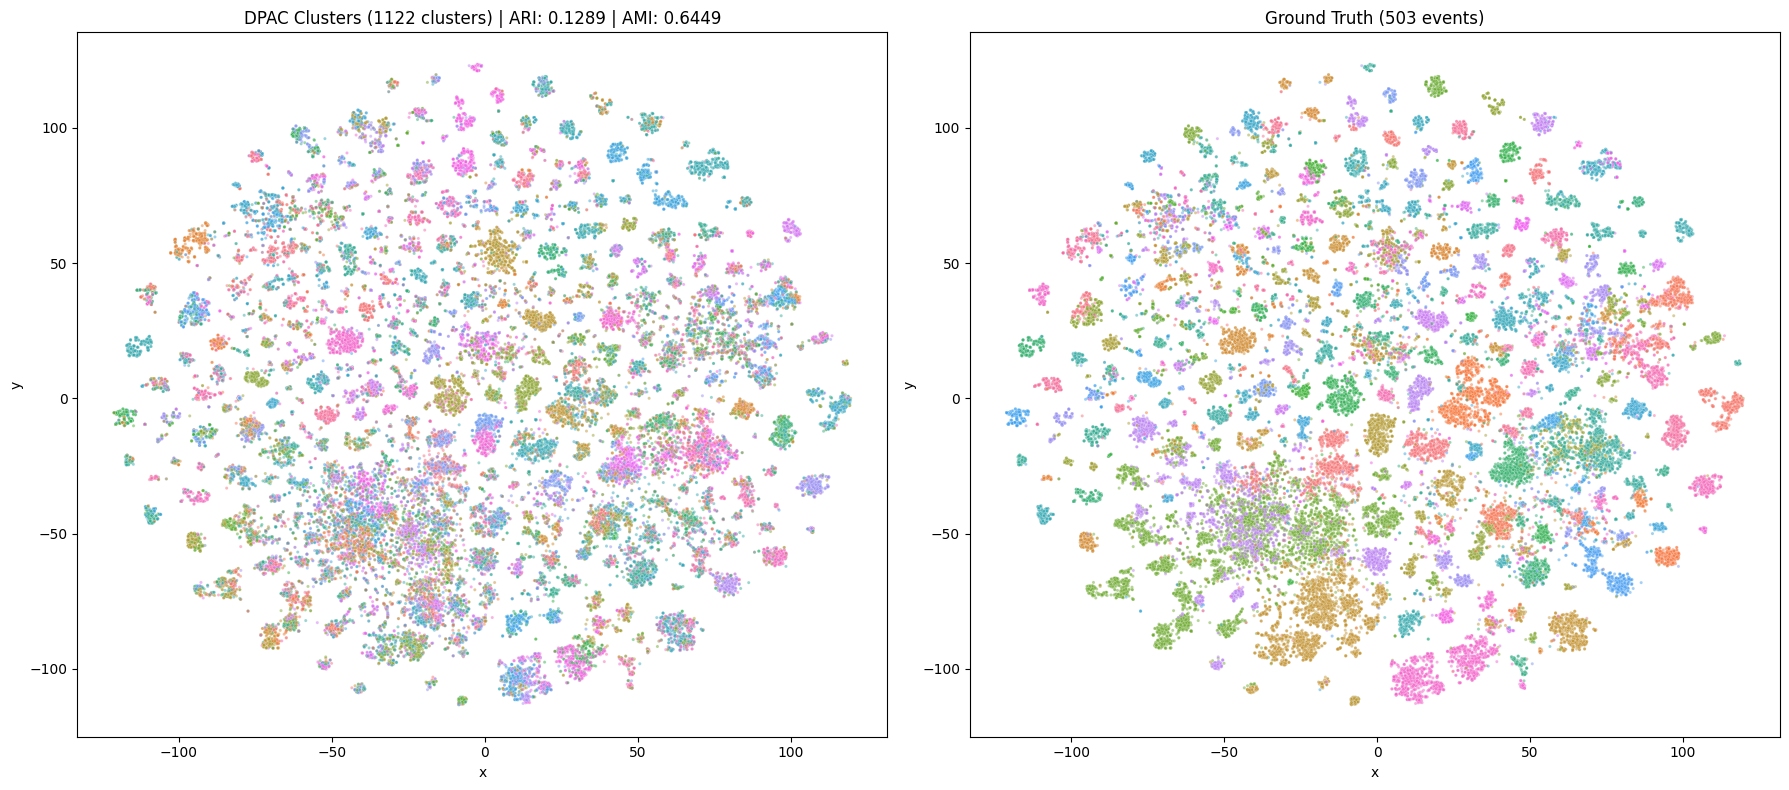

In [34]:
plt.figure(figsize=(18, 8))

# Left: DPAC Predictions
plt.subplot(1, 2, 1)
sns.scatterplot(data=plot_df_dpac, x='x', y='y', hue='Preds', palette=pred_color_dict, legend=False, s=5, alpha=0.5)
plt.title(f"DPAC Clusters ({len(np.unique(preds))} clusters) | ARI: {ari:.4f} | AMI: {ami:.4f}")

# Right: Ground Truth
plt.subplot(1, 2, 2)
sns.scatterplot(data=plot_df_dpac, x='x', y='y', hue='Truth', palette=gt_color_dict, legend=False, s=5, alpha=0.5)
plt.title(f"Ground Truth ({len(np.unique(y_true))} events)")

plt.tight_layout()
plt.show()

In [ ]:
# parser = argparse.ArgumentParser()
# parser.add_argument('-dataset-name', default='cifar10',
#                     help='dataset name',
#                     choices=['stl10', 'cifar10', 'cifar100', 'imagenet10', 'imagenet_dogs', 'tiny_imagenet'])
# parser.add_argument('-data', metavar='DIR', default='./datasets',
#                     help='path to dataset')
# parser.add_argument('-model-path', default='./save/CIFAR-10',
#                     help='path to save model')
# # Training Hyper parameter
# parser.add_argument('--epochs', default=200, type=int, metavar='N',
#                     help='number of total epochs to run')
# parser.add_argument('-b', '--batch-size', default=256, type=int,
#                     metavar='N',
#                     help='mini-batch size (default: 240), this is the total '
#                          'batch size of all GPUs on the current node when '
#                          'using Data Parallel or Distributed Data Parallel')
# parser.add_argument('--lr', '--learning-rate', default=1e-4, type=float,
#                     metavar='LR', help='initial learning rate', dest='lr')
# parser.add_argument('--wd', '--weight-decay', default=1e-4, type=float,
#                     metavar='W', help='weight decay (default: 1e-4)',
#                     dest='weight_decay')
# parser.add_argument('--resnet', default='ResNet34', help='Choice resnet.')

# # Hyper parameter
# parser.add_argument('--temperature', default=0.5, type=float, help='softmax temperature (default: 0.5)')
# parser.add_argument('--m', default=1.03, type=float, help='weight exponent > 1 (default: 1.03)')
# parser.add_argument('--thd', default=0.99, type=float, help='threshold of pseudo label (default: 0.95)')

# # Deployment
# parser.add_argument('--gpu-index', default=0, type=int, help='Gpu index.')
# parser.add_argument('--seed', default=0, type=int)


# # NEW!!! I ADDED THIS!!!
# def kldiv(q, p):
#     """
#     Standard KL Divergence for clustering.
#     q: Target distribution (sharpened)
#     p: Predicted distribution
#     """
#     res = -torch.sum(q * torch.log(p + 1e-8), dim=-1)
#     return res.mean()
    

# def pac_loss(p, f):
#     N, C = p.shape
#     p = F.softmax(p, dim=1)
#     dis = 1 - 1 * torch.matmul(f, f.T)
#     ps = torch.mm(p, p.T)
#     loss = (dis * ps).sum(1)
#     return loss.sum() / N


# def model(args, ins_loader, optimizer, criterion, model, scaler):
#     loss_epoch = {'loss1': 0, 'loss2': 0, 'loss3': 0}
#     for step, ((weak, strong, ori), _) in enumerate(ins_loader):
#         weak = weak.to(args.device)
#         strong = strong.to(args.device)
#         img = torch.cat((weak, strong), dim=0)
#         ori = ori.to(args.device)
#         optimizer.zero_grad()
#         with torch.cuda.amp.autocast():
#             z, p1, u2 = model(img)
#             q, p = model.PAC_online(ori, m=args.m)  # clustering codes
#             # loss1 = criterion(z, p)  # contrastive learning
#             loss1 = criterion(z)
#             loss2 = kldiv(q, p1)  # online clustering
#             """ self-labeling fine-tuning same as Fixmatch"""
#             # max_probs, tragets_p = torch.max(F.softmax(p1, dim=1), dim=-1)  # pseudo labels
#             # mask = max_probs.ge(args.thd).float()
#             # loss3 = (F.cross_entropy(u2, tragets_p, reduction='none') * mask).mean()  # self-labeling
#             loss = loss1 + loss2
#         scaler.scale(loss).backward()
#         scaler.step(optimizer)
#         scaler.update()
#         loss_epoch['loss1'] += loss1.item() / len(ins_loader)
#         loss_epoch['loss2'] += loss2.item() / len(ins_loader)
#         # loss_epoch['loss3'] += loss3.item() / len(ins_loader)
#     return model, loss_epoch


# def main():
#     """ DPAC """
#     args = parser.parse_args()
#     args.device = torch.device(f'cuda:{args.gpu_index}')
#     torch.cuda.set_device(args.gpu_index)
#     print(f'select device:cuda{args.gpu_index}')
#     torch.manual_seed(args.seed)
#     torch.cuda.manual_seed_all(args.seed)
#     torch.cuda.manual_seed(args.seed)
#     np.random.seed(args.seed)

#     dataset = ContrastiveLearningDataset(args.data)
#     ins_dataset, class_num = dataset.get_dataset(args.dataset_name, dataset=True)
#     ins_loader = DataLoader(ins_dataset, batch_size=args.batch_size, shuffle=True, pin_memory=True,
#                                   num_workers=4, drop_last=True)
#     if args.dataset_name == 'cifar10' or args.dataset_name == 'cifar100':
#         res = get_resnet_cifar(args.resnet)
#     elif args.dataset_name == 'stl10':
#         res = get_resnet_stl(args.resnet)
#     else:
#         res = get_resnet(args.resnet)
#     model = Network(res, res.rep_dim, class_num)
#     model = model.to(args.device)
#     checkpoint = torch.load('./save/CL_1000.tar', map_location=args.device)
#     model.load_state_dict(checkpoint['net'], strict=False)
#     optimizer = torch.optim.Adam(model.parameters(), 1e-4, weight_decay=1e-4)
#     criterion = InfonceLoss(args.batch_size, args.temperature, args.device).to(args.device)
#     torch.backends.cudnn.benchmark = True
#     torch.backends.cuda.matmul.allow_tf32 = True
#     torch.backends.cudnn.allow_tf32 = True
#     scaler = torch.cuda.amp.GradScaler()

#     for epoch_counter in tqdm(range(args.epochs)):
#         model, loss_epoch = model(args, ins_loader, optimizer, criterion, model, scaler)
#         print(
#             f"Epoch [{epoch_counter}/{args.epochs}]\t "
#             f"loss1_epoch: {loss_epoch['loss1']}\t "
#             f"loss2_epoch: {loss_epoch['loss2']}\t "
#             f"loss3_epoch: {loss_epoch['loss3']}\t "
#         )
#         save_model(args, model, optimizer)


# if __name__ == '__main__':
#     main()
